# Подготовка базы

In [ ]:
import numpy as np
import pandas as pd
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.layers import Dense, Activation, Input
from tensorflow.keras import utils
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
%matplotlib inline

In [ ]:
df = pd.read_csv("sonar.csv", header=None)
print(df.shape)
df.head()

(208, 61)


,0,1,2,3,4,5,6,7,8,9,...,51,52,53,54,55,56,57,58,59,60
0,0.0200,0.0371,0.0428,0.0207,0.0954,0.0986,0.1539,0.1601,0.3109,0.2111,...,0.0027,0.0065,0.0159,0.0072,0.0167,0.0180,0.0084,0.0090,0.0032,R
1,0.0453,0.0523,0.0843,0.0689,0.1183,0.2583,0.2156,0.3481,0.3337,0.2872,...,0.0084,0.0089,0.0048,0.0094,0.0191,0.0140,0.0049,0.0052,0.0044,R
2,0.0262,0.0582,0.1099,0.1083,0.0974,0.2280,0.2431,0.3771,0.5598,0.6194,...,0.0232,0.0166,0.0095,0.0180,0.0244,0.0316,0.0164,0.0095,0.0078,R
3,0.0100,0.0171,0.0623,0.0205,0.0205,0.0368,0.1098,0.1276,0.0598,0.1264,...,0.0121,0.0036,0.0150,0.0085,0.0073,0.0050,0.0044,0.0040,0.0117,R
4,0.0762,0.0666,0.0481,0.0394,0.0590,0.0649,0.1209,0.2467,0.3564,0.4459,...,0.0031,0.0054,0.0105,0.0110,0.0015,0.0072,0.0048,0.0107,0.0094,R


In [ ]:
dataset = df.replace('R', 1.).replace('M', 0.).astype(float).to_numpy()

x_data = dataset[:, :60]
y_data = dataset[:, 60]

print('Размерность набора параметров объектов', x_data.shape)
print('Размерность набора меток класса', y_data.shape)
print()
print('Содержание y_data:', y_data)

Размерность набора параметров объектов (208, 60)
Размерность набора меток класса (208,)

Содержание y_data: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


/tmp/ipykernel_1457/4131486058.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  dataset = df.replace('R', 1.).replace('M', 0.).astype(float).to_numpy()


In [ ]:
#функция случайно делит датасет на обучающую и тестовые части
x_train, x_test, y_train, y_test = train_test_split(
    x_data,        # параметры
    y_data,        # метки классов
    test_size=0.2, # процент в тестовую
    shuffle=True,  # перемешивание
    random_state=3 # воспроизводимость
)

print('Обучающая выборка параметров', x_train.shape)
print('Обучающая выборка меток классов', y_train.shape)
print()
print('Тестовая выборка параметров', x_test.shape)
print('Тестовая выборка меток классов', y_test.shape)

Обучающая выборка параметров (1600, 20)
Обучающая выборка меток классов (1600, 4)

Тестовая выборка параметров (400, 20)
Тестовая выборка меток классов (400, 4)


# Обучение нейросети

In [ ]:
def create_model():
  # Создание модели
    model = Sequential()
    # Добавление слоев
    model.add(Input(shape=(x_train.shape[1],)))   # слой 0: вход
    model.add(Dense(60, activation='relu'))       # слой 1
    model.add(Dense(30, activation='relu'))       # слой 2
    model.add(Dense(4, activation='sigmoid'))     # слой 3: выход
# Компиляция и возврат модели
    model.compile(loss='binary_crossentropy',
                  optimizer=Adam(learning_rate=0.001),
                  metrics=['accuracy'])
    return model

model = create_model()
model.summary()

Model: "sequential_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_41 (Dense)                │ (None, 60)             │         1,260 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_42 (Dense)                │ (None, 30)             │         1,830 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_43 (Dense)                │ (None, 4)              │           124 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,214 (12.55 KB)

 Trainable params: 3,214 (12.55 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
print("y_train.shape:", y_train.shape)          # ожидается (1600, 4)
print("model.output_shape:", model.output_shape) # ожидается (None, 4)
print("Совпадает:", y_train.shape[1] == model.output_shape[1])

y_train.shape: (1600, 4)
model.output_shape: (None, 4)
Совпадает: True


# Оценка качества обучения

Создание  валидационной выборки.

In [ ]:
# Обучение нейронной сети
history = model.fit(x_train,               # Обучающая выборка параметров
          y_train,               # Обучающая выборка меток класса
          batch_size=8,          # Размер батча (пакета)
          epochs=100,            # Количество эпох обучения
          validation_split=0.2,  # Доля проверочной выборки
          verbose=1)             # Отображение хода обучения


Epoch 1/100
160/160 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.4430 - loss: 0.5336 - val_accuracy: 0.5656 - val_loss: 0.4505
Epoch 2/100
160/160 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6898 - loss: 0.3684 - val_accuracy: 0.6844 - val_loss: 0.3337
Epoch 3/100
160/160 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8109 - loss: 0.2844 - val_accuracy: 0.7719 - val_loss: 0.2820
Epoch 4/100
160/160 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8805 - loss: 0.2298 - val_accuracy: 0.8219 - val_loss: 0.2369
Epoch 5/100
160/160 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9164 - loss: 0.1834 - val_accuracy: 0.8344 - val_loss: 0.2073
Epoch 6/100
160/160 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9398 - loss: 0.1454 - val_accuracy: 0.8906 - val_loss: 0.1747
Epoch 7/100
160/160 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9508 - loss: 0.1174 - val_accuracy: 0.9094 - val_loss: 0.1588
Epoch 8/100
160/160 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9688 - loss: 0.0950 - val_accu

 Посмотреть точность на проверочной выборке

In [ ]:
scores = model.evaluate(x_test,
                        y_test,
                        verbose=1
                        )


13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9075 - loss: 0.2266 


# Визуализация качества обучения

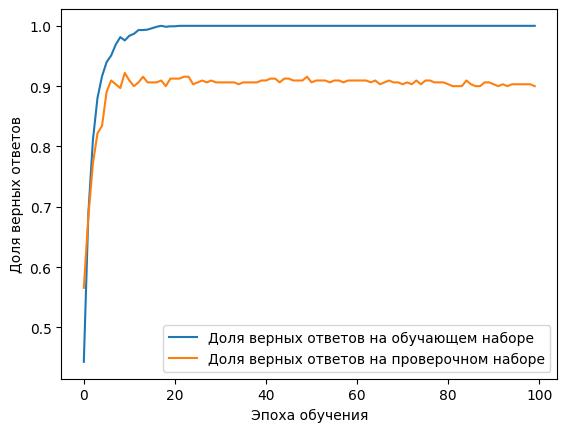

In [ ]:
# Визуализация точности на обучающей выборке
plt.plot(history.history['accuracy'],
         label='Доля верных ответов на обучающем наборе')

# Визуализация точности на проверочной выборке
plt.plot(history.history['val_accuracy'],
         label='Доля верных ответов на проверочном наборе')

# Отрисовка подписей осей
plt.xlabel('Эпоха обучения')
plt.ylabel('Доля верных ответов')

# Отрисовка легенды
plt.legend()

# Вывод графика
plt.show()


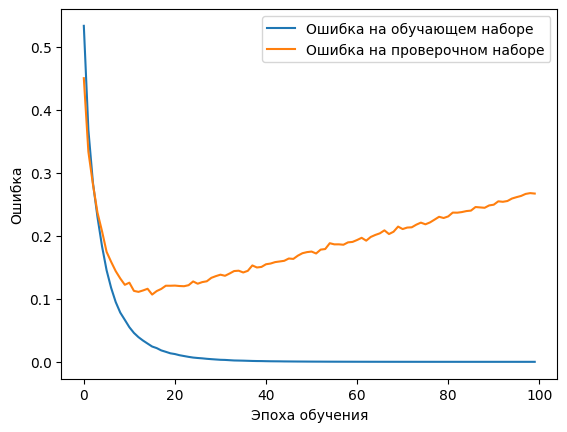

In [ ]:
#График ошибки
plt.plot(history.history['loss'],
         label='Ошибка на обучающем наборе')
plt.plot(history.history['val_loss'],
         label='Ошибка на проверочном наборе')

plt.xlabel('Эпоха обучения')
plt.ylabel('Ошибка')

plt.legend()

plt.show()



# Слой Dropout

In [ ]:
# Создание последовательной модели
model = Sequential()
model.add(Input(shape=(x_train.shape[1],)))
model.add(Dense(60, activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(30, activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(4, activation='sigmoid'))

# Компиляция модели
model.compile(loss='binary_crossentropy', optimizer=Adam(learning_rate=0.001), metrics=['accuracy'])

# Обучение сети
history = model.fit(x_train,
                    y_train,
                    batch_size=8,
                    epochs=200,
                    validation_split=0.2,
                    verbose=1)


Epoch 1/200
160/160 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.3063 - loss: 0.6151 - val_accuracy: 0.4781 - val_loss: 0.5271
Epoch 2/200
160/160 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.4617 - loss: 0.5071 - val_accuracy: 0.5437 - val_loss: 0.4310
Epoch 3/200
160/160 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5641 - loss: 0.4214 - val_accuracy: 0.6250 - val_loss: 0.3557
Epoch 4/200
160/160 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.6570 - loss: 0.3560 - val_accuracy: 0.6938 - val_loss: 0.3091
Epoch 5/200
160/160 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.6898 - loss: 0.3178 - val_accuracy: 0.7469 - val_loss: 0.2771
Epoch 6/200
160/160 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.7555 - loss: 0.2863 - val_accuracy: 0.7656 - val_loss: 0.2553
Epoch 7/200
160/160 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7805 - loss: 0.2566 - val_accuracy: 0.7906 - val_loss: 0.2299
Epoch 8/200
160/160 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8148 - loss: 0.2412 - val_accu

Model: "sequential_16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_50 (Dense)                │ (None, 60)             │         1,260 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 60)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_51 (Dense)                │ (None, 30)             │         1,830 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 30)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_52 (Dense)                │ (None, 4)              │           124 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,644 (37.68 KB)

 Trainable params: 3,214 (12.55 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 6,430 (25.12 KB)

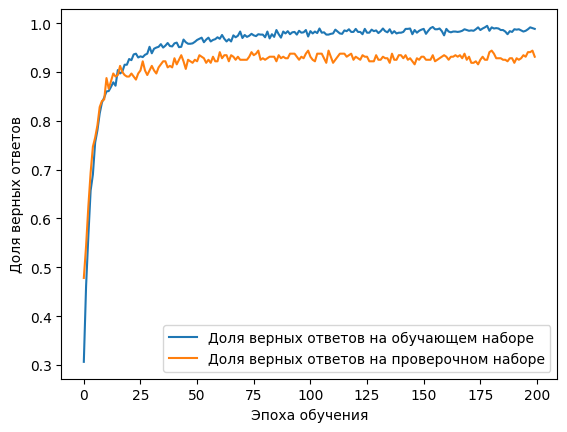

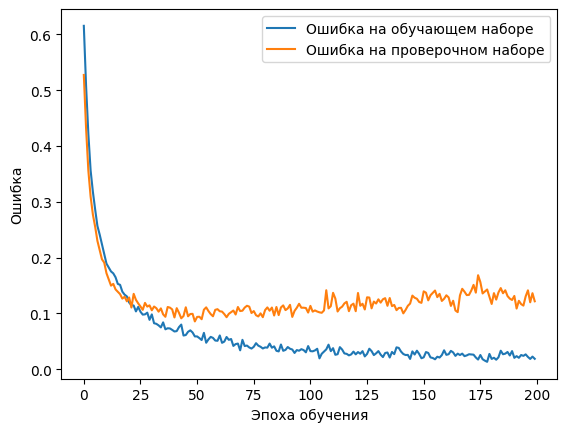

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9350 - loss: 0.1190  
[0.1190338209271431, 0.9350000023841858]
Доля верных ответов на тестовых данных, в процентах: 93.5000%


In [ ]:
# Краткая сводка архитектуры модели
model.summary()
# Отрисовка графика точности на обучающей выборке
# label - имя графика в легенде
plt.plot(history.history['accuracy'],
         label='Доля верных ответов на обучающем наборе')
plt.plot(history.history['val_accuracy'],
         label='Доля верных ответов на проверочном наборе')
plt.xlabel('Эпоха обучения')
plt.ylabel('Доля верных ответов')
plt.legend()
plt.show()
# Вывод графика ошибки
plt.plot(history.history['loss'],
         label='Ошибка на обучающем наборе')
plt.plot(history.history['val_loss'],
         label='Ошибка на проверочном наборе')
plt.xlabel('Эпоха обучения')
plt.ylabel('Ошибка')
plt.legend()
plt.show()

# Вычисление результата (предсказания) сети на тестовом наборе
scores = model.evaluate(x_test, y_test, verbose=1)

print(scores)
print('Доля верных ответов на тестовых данных, в процентах: {:7.4%}'.format(scores[1]))

Слой BatchNormalization
Изменим архитектуру сети, добавим слой BatchNormalization


Epoch 1/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 62ms/step - accuracy: 0.2859 - loss: 0.7607 - val_accuracy: 0.2531 - val_loss: 0.6938
Epoch 2/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.3164 - loss: 0.6799 - val_accuracy: 0.2562 - val_loss: 0.6642
Epoch 3/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.3633 - loss: 0.6205 - val_accuracy: 0.2812 - val_loss: 0.6373
Epoch 4/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.4242 - loss: 0.5717 - val_accuracy: 0.2969 - val_loss: 0.6135
Epoch 5/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.4633 - loss: 0.5353 - val_accuracy: 0.3250 - val_loss: 0.5920
Epoch 6/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.5063 - loss: 0.5047 - val_accuracy: 0.3500 - val_loss: 0.5722
Epoch 7/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.5539 - loss: 0.4773 - val_accuracy: 0.3625 - val_loss: 0.5535
Epoch 8/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.5906 - loss: 0.4551 - val_accuracy: 0.4187 - val_loss:

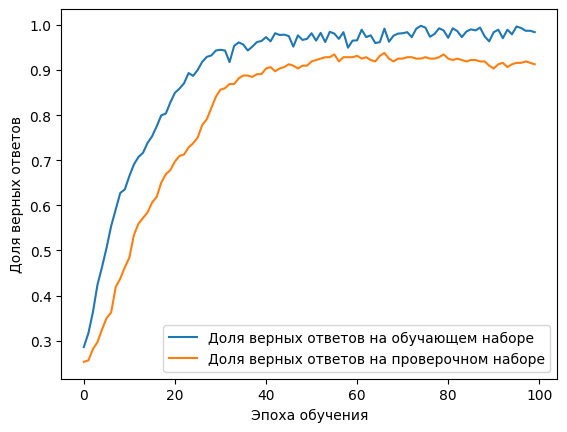

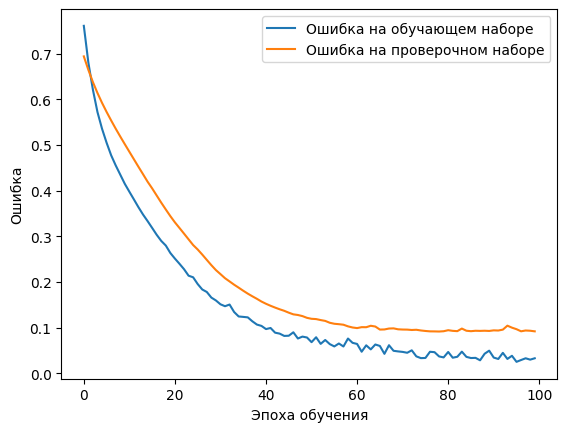

In [ ]:
model = Sequential()

model.add(BatchNormalization(input_shape=(x_train.shape[1], )))
model.add(Dense(60, activation='relu'))
model.add(BatchNormalization())
model.add(Dense(30, activation='relu'))
model.add(Dense(4, activation='sigmoid'))

model.compile(loss='binary_crossentropy',
              optimizer=Adam(learning_rate=0.001),
              metrics=['accuracy'])

history = model.fit(x_train,
                    y_train,
                    batch_size=200,
                    epochs=100,
                    validation_split=0.2,
                    verbose=1)

plt.plot(history.history['accuracy'],
         label='Доля верных ответов на обучающем наборе')
plt.plot(history.history['val_accuracy'],
         label='Доля верных ответов на проверочном наборе')
plt.xlabel('Эпоха обучения')
plt.ylabel('Доля верных ответов')
plt.legend()
plt.show()

plt.plot(history.history['loss'],
         label='Ошибка на обучающем наборе')
plt.plot(history.history['val_loss'],
         label='Ошибка на проверочном наборе')
plt.xlabel('Эпоха обучения')
plt.ylabel('Ошибка')
plt.legend()
plt.show()


# Практическое задание 1

/usr/local/lib/python3.13/dist-packages/keras/src/layers/normalization/batch_normalization.py:142: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/200
160/160 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.3242 - loss: 1.7325 - val_accuracy: 0.4437 - val_loss: 1.2059
Epoch 2/200
160/160 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.4109 - loss: 1.3228 - val_accuracy: 0.5625 - val_loss: 0.9483
Epoch 3/200
160/160 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5016 - loss: 1.0767 - val_accuracy: 0.6594 - val_loss: 0.7857
Epoch 4/200
160/160 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5477 - loss: 0.9761 - val_accuracy: 0.7000 - val_loss: 0.6897
Epoch 5/200
160/160 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6062 - loss: 0.8999 - val_accuracy: 0.7469 - val_loss: 0.6137
Epoch 6/200
160/160 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6055 - loss: 0.8630 - val_accuracy: 0.7719 - val_loss: 0.5703
Epoch 7/200
160/160 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6594 - loss: 0.7895 - val_accuracy: 0.8062 - val_loss: 0.5303
Epoch 8/200
160/160 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6484 - loss: 0.7896 - val_accu

Model: "sequential_26"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ batch_normalization_26          │ (None, 20)             │            80 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_82 (Dense)                │ (None, 60)             │         1,260 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_27          │ (None, 60)             │           240 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_26 (Dropout)            │ (None, 60)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_83 (Dense)                │ (None, 30)             │         1,830 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_28          │ (None, 30)             │           120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_27 (Dropout)            │ (None, 30)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_84 (Dense)                │ (None, 4)              │           124 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,524 (41.11 KB)

 Trainable params: 3,434 (13.41 KB)

 Non-trainable params: 220 (880.00 B)

 Optimizer params: 6,870 (26.84 KB)

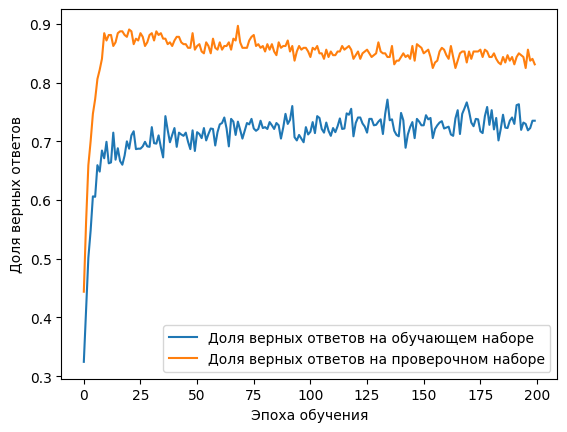

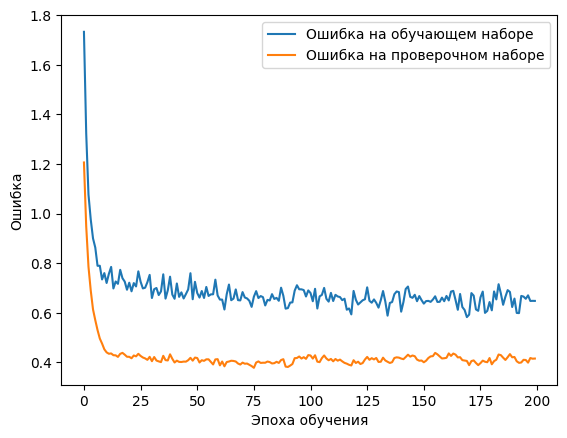

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8425 - loss: 0.4061  
Доля верных ответов на тестовых данных: 84.2500%


In [ ]:
model = Sequential()
#нормализует входные данные перед подачей в сеть.
model.add(BatchNormalization(input_shape=(x_train.shape[1],)))


model.add(Dense(60, activation='relu')) #1 слой
model.add(BatchNormalization()) #нормализует выходы 1-го слоя
model.add(Dropout(0.3)) #защита от переобучения (отключения 30 нейронов на каждой эпохи)

model.add(Dense(30, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.3))

model.add(Dense(4, activation='softmax'))

#для 4 классов categorical_crossentropy
model.compile(loss='categorical_crossentropy',
              optimizer=Adam(learning_rate=0.001),
              metrics=['accuracy'])

#запуск обучения
history = model.fit(x_train,              #Признаки для обучения
                    y_train,              #Метки (one-hot) для обучения
                    batch_size=8,         #Сколько объектов обрабатывается за один шаг
                    epochs=200,           #Сколько раз пройти по всему датасету
                    validation_split=0.2, #Keras отрежет 20% от x_train для валидации
                    verbose=1)            #Показывать прогресс-бар

model.summary()

# Графики
plt.plot(history.history['accuracy'], label='Доля верных ответов на обучающем наборе')
plt.plot(history.history['val_accuracy'], label='Доля верных ответов на проверочном наборе')
plt.xlabel('Эпоха обучения')
plt.ylabel('Доля верных ответов')
plt.legend()
plt.show()

plt.plot(history.history['loss'], label='Ошибка на обучающем наборе')
plt.plot(history.history['val_loss'], label='Ошибка на проверочном наборе')
plt.xlabel('Эпоха обучения')
plt.ylabel('Ошибка')
plt.legend()
plt.show()

scores = model.evaluate(x_test, y_test, verbose=1)
print('Доля верных ответов на тестовых данных: {:7.4%}'.format(scores[1]))

# Практическое задание

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split   # ← добавлен импорт

# --- Загрузка ---
df = pd.read_csv("train.csv", sep=';')   # разделитель ';'
print("Размер:", df.shape)

# --- Признаки и метки ---
x_data = df.drop('price_range', axis=1).to_numpy()  # все колонки кроме метки — признаки
y_data = df['price_range'].to_numpy()                # колонка price_range — метки (0..3)

# --- Масштабирование ---
scaler = StandardScaler()                  # приводит признаки к μ=0, σ=1
x_data = scaler.fit_transform(x_data)      # обучаем scaler на данных и применяем

# --- One-hot encoding для 4 классов ---
y_data = to_categorical(y_data, num_classes=4)

# --- Разделение ---
x_train, x_test, y_train, y_test = train_test_split(
    x_data,              # признаки
    y_data,              # метки (one-hot)
    test_size=0.2,       # 20% в тестовую выборку
    random_state=42,     # воспроизводимость
    stratify=y_data      # сохранить пропорции 4 классов
)

print("x_train:", x_train.shape, "y_train:", y_train.shape)  # (1600, 20) (1600, 4)
print("x_test :", x_test.shape,  "y_test :", y_test.shape)   # (400, 20)  (400, 4)

Размер: (2000, 21)
x_train: (1600, 20) y_train: (1600, 4)
x_test : (400, 20) y_test : (400, 4)


Архитектуры


In [ ]:
def model_v1():
    """Простая модель: 2 скрытых слоя без регуляризации."""
    model = Sequential([
        Input(shape=(x_train.shape[1],)),   # форма входа: 20 признаков
        Dense(64, activation='relu'),        # 1-й скрытый слой, 64 нейрона
        Dense(32, activation='relu'),        # 2-й скрытый слой, 32 нейрона
        Dense(4, activation='softmax')       # выход: 4 класса (0..3)
    ])
    model.compile(loss='categorical_crossentropy',   # для one-hot меток
                  optimizer=Adam(learning_rate=0.001),# шаг обучения 0.001
                  metrics=['accuracy'])               # следим за точностью
    return model

In [ ]:
def model_v2():
    """Модель с BatchNormalization + Dropout — против переобучения."""
    model = Sequential([
        Input(shape=(x_train.shape[1],)),    # форма входа: 20 признаков

        Dense(128, activation='relu'),       # 1-й скрытый слой, 128 нейронов
        BatchNormalization(),                # нормализует выходы 1-го слоя
        Dropout(0.4),                        # выключает 40% нейронов → защита от переобучения

        Dense(64, activation='relu'),        # 2-й скрытый слой, 64 нейрона
        BatchNormalization(),                # нормализует выходы 2-го слоя
        Dropout(0.3),                        # выключает 30% нейронов

        Dense(32, activation='relu'),        # 3-й скрытый слой, 32 нейрона
        Dense(4, activation='softmax')       # выход: 4 класса
    ])
    model.compile(loss='categorical_crossentropy',   # для one-hot меток
                  optimizer=Adam(learning_rate=0.0005),# шаг меньше — стабильнее
                  metrics=['accuracy'])
    return model

--- Модель V1 ---
Точность на тесте (V1): 0.9100


Model: "sequential_24"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_75 (Dense)                │ (None, 64)             │         1,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_76 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_77 (Dense)                │ (None, 4)              │           132 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,670 (41.68 KB)

 Trainable params: 3,556 (13.89 KB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_78 (Dense)                │ (None, 128)            │         2,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_24          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_24 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_79 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_25          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_25 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_80 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_81 (Dense)                │ (None, 4)              │           132 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 41,006 (160.18 KB)

 Trainable params: 13,540 (52.89 KB)

 Non-trainable params: 384 (1.50 KB)

 Optimizer params: 27,082 (105.79 KB)

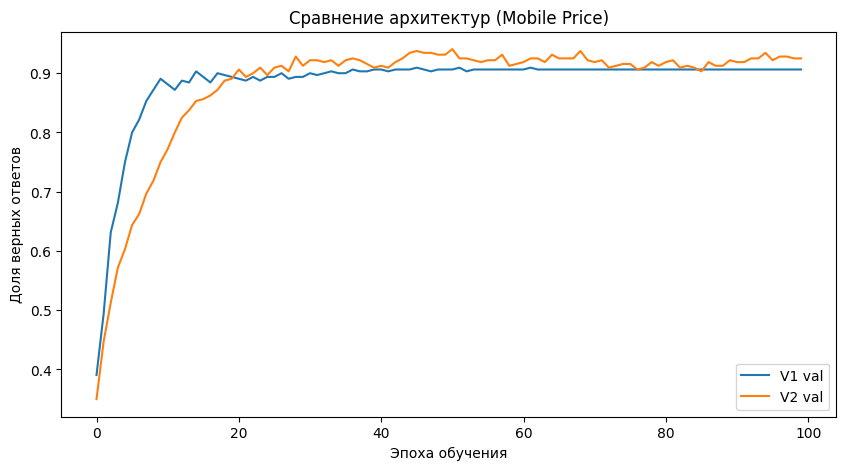


Итог:
  V1: 91.0000%
  V2: 92.7500%


In [ ]:
# --- Обучение и сравнение ---
plt.figure(figsize=(10, 5))
results = {}

for name, create_fn in [('V1', model_v1), ('V2', model_v2)]:
    print(f'--- Модель {name} ---')

    model = create_fn()              # создаём НОВУЮ модель для каждой архитектуры
    history = model.fit(x_train, y_train,       # признаки и метки для обучения
                        batch_size=32,          # 32 объекта за один шаг
                        epochs=100,             # 100 проходов по датасету
                        validation_split=0.2,   # 20% train уйдёт в валидацию
                        verbose=0)              # без прогресс-бара

    # Кривая точности на валидации для текущей модели
    plt.plot(history.history['val_accuracy'], label=f'{name} val')

    # Оценка на отложенной тестовой выборке
    scores = model.evaluate(x_test, y_test, verbose=0)  # [loss, accuracy]
    results[name] = scores[1]        # запоминаем accuracy
    print(f'Точность на тесте ({name}): {scores[1]:.4f}')

    model.summary()                  # архитектура модели

# Оформление графика
plt.xlabel('Эпоха обучения')         # подпись оси X
plt.ylabel('Доля верных ответов')    # подпись оси Y
plt.legend()                         # легенда с именами V1/V2
plt.title('Сравнение архитектур (Mobile Price)')
plt.show()

# --- Итог ---
print("\nИтог:")
for k, v in results.items():
    print(f'  {k}: {v:.4%}')         # вывод в процентах